<a href="https://colab.research.google.com/github/Anuska111/House_Price_Prediction_Local/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline



In [11]:
df=pd.read_csv("/content/Bengaluru_House_Data.csv")
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [66]:
df4 = pd.read_csv("/content/Bengaluru_House_Data.csv")

In [67]:
display(df4.head())

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [15]:
df["availability"].value_counts()

,count
availability,
Ready To Move,10581
18-Dec,307
18-May,295
18-Apr,271
18-Aug,200
...,...
16-Oct,1
17-Jan,1
16-Nov,1


<Axes: >

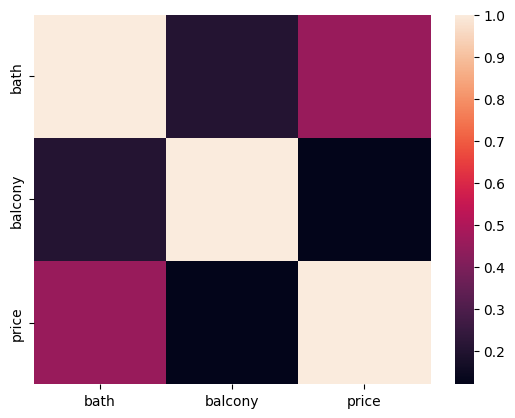

In [16]:
corr=df.select_dtypes("number").corr()
sns.heatmap(corr)

In [17]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [18]:
df1=df.drop(columns=['area_type','society','balcony','availability'])

In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [20]:
df1.dropna(inplace=True)

In [21]:
df1.isnull().sum()

,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [22]:

df1['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK', '18 Bedroom'], dtype=object)

In [23]:
df1['bedrooms']=df1['size'].apply(lambda x: int(x.split(" ")[0]))

In [24]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13246 non-null  object 
 1   size        13246 non-null  object 
 2   total_sqft  13246 non-null  object 
 3   bath        13246 non-null  float64
 4   price       13246 non-null  float64
 5   bedrooms    13246 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 724.4+ KB


In [25]:
df1.head()

,location,size,total_sqft,bath,price,bedrooms
0,Electronic City Phase II,2 BHK,1056,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,51.00,2


In [26]:
df1=df1.drop(columns='size')

In [27]:
df1['bedrooms'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [28]:
df1[df1.bedrooms>20]

,location,total_sqft,bath,price,bedrooms
1718,2Electronic City Phase II,8000,27.0,230.0,27
4684,Munnekollal,2400,40.0,660.0,43


In [29]:
df1['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [30]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

In [31]:
df1[~df1['total_sqft'].apply(is_float)].head(10)

,location,total_sqft,bath,price,bedrooms
30,Yelahanka,2100 - 2850,4.0,186.000,4
122,Hebbal,3067 - 8156,4.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,43.490,2
188,KR Puram,1015 - 1540,2.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,63.770,2
648,Arekere,4125Perch,9.0,265.000,9
661,Yelahanka,1120 - 1145,2.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,445.000,4


In [32]:
def convert_sqft_to_num(x):
    if isinstance(x,float):
        return x
    tokens=str(x).split('-')
    if len(tokens)==2:
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None

In [33]:
df4=df1.copy()
df4['total_sqft']=df4['total_sqft'].apply(convert_sqft_to_num)
df4.dropna(inplace=True)
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 618.8+ KB


Applying the `convert_sqft_to_num` function to the `total_sqft` column to transform its values into a numerical format, handling ranges by taking their average and setting unparseable strings to `None` (which Pandas converts to `NaN`).

In [34]:
df1['total_sqft'] = df1['total_sqft'].apply(convert_sqft_to_num)

Now, let's check for any `NaN` values that resulted from the conversion process in the `total_sqft` column.

In [35]:
df1.isnull().sum()

,0
location,0
total_sqft,46
bath,0
price,0
bedrooms,0


Since we have a relatively small number of `NaN`s in `total_sqft` after conversion, I'll drop these rows to ensure our dataset contains only valid numerical values for this column.

In [36]:
df1.dropna(inplace=True)

Finally, let's verify the DataFrame's information to confirm that `total_sqft` is now a numerical type and that there are no more null values.

In [37]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13200 non-null  object 
 1   total_sqft  13200 non-null  float64
 2   bath        13200 non-null  float64
 3   price       13200 non-null  float64
 4   bedrooms    13200 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 618.8+ KB


{'whiskers': [<matplotlib.lines.Line2D at 0x7dcdfdf47a40>,
 'caps': [<matplotlib.lines.Line2D at 0x7dcdfdf46c00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dcdfdf47440>],
 'medians': [<matplotlib.lines.Line2D at 0x7dcdfdf467b0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dcdfdf464e0>],
 'means': []}

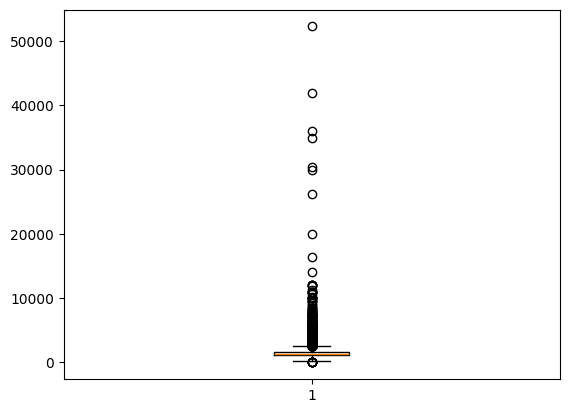

In [38]:
plt.boxplot(df4['total_sqft'])

In [39]:
low,high=df4['total_sqft'].quantile([0.1,0.9])
mask_area=df4['total_sqft'].between(low,high)
df4=df4[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x7dcdfebca030>,
 'caps': [<matplotlib.lines.Line2D at 0x7dcdfebca5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dcdfebc9d60>],
 'medians': [<matplotlib.lines.Line2D at 0x7dcdfebaf650>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dcdfebcad50>],
 'means': []}

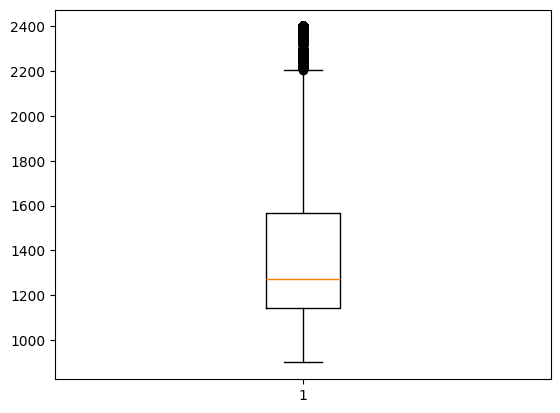

In [40]:
plt.boxplot(df4['total_sqft'])

In [41]:
df4['bath'].describe()

,bath
count,10594.000000
mean,2.556069
std,1.088512
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,40.000000


{'whiskers': [<matplotlib.lines.Line2D at 0x7dcdfdf442c0>,
 'caps': [<matplotlib.lines.Line2D at 0x7dcdfea2ecc0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dcdfec17aa0>],
 'medians': [<matplotlib.lines.Line2D at 0x7dcdfea2f2c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dcdfea2f590>],
 'means': []}

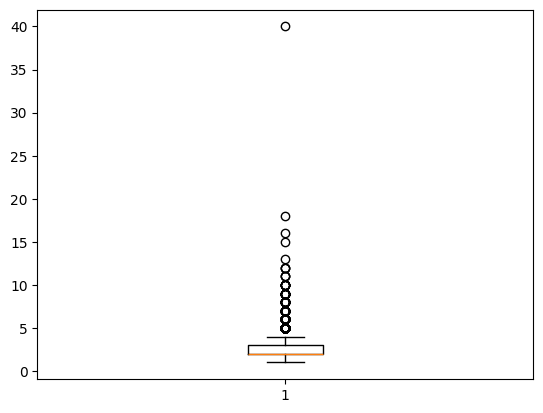

In [42]:
plt.boxplot(df4['bath'])

In [43]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


In [44]:
df4=df4[df4['bath']<12]

In [47]:
df4['bath'].value_counts()

,count
bath,
2.0,6468
3.0,2933
4.0,632
5.0,190
1.0,135
6.0,117
7.0,46
8.0,31
9.0,22


{'whiskers': [<matplotlib.lines.Line2D at 0x7dcdfeacfda0>,
 'caps': [<matplotlib.lines.Line2D at 0x7dcdfeb043b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dcdfeacfaa0>],
 'medians': [<matplotlib.lines.Line2D at 0x7dcdfeb04950>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dcdfeb04c50>],
 'means': []}

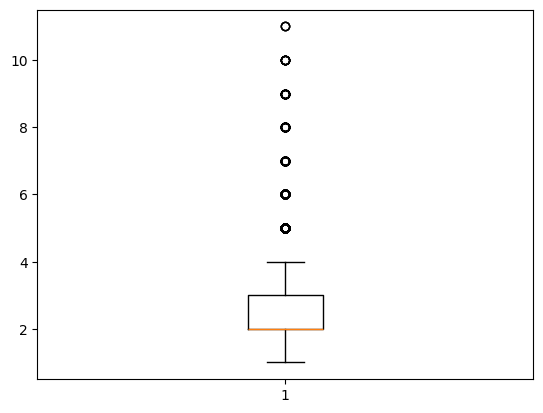

In [49]:
plt.boxplot(df4['bath'])

In [88]:
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4.dropna(subset=['total_sqft'], inplace=True)
df4['price_per_sqft']=df4['price']*100000/df4['total_sqft']

In [52]:
df4.head()

,location,total_sqft,bath,price,bedrooms,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,39.07,2,3699.810606
2,Uttarahalli,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,1170.0,2.0,38.00,2,3247.863248


In [54]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,10586.000000
mean,6244.315309
std,3698.326765
min,500.000000
25%,4206.709513
50%,5252.421226
75%,6761.335502
max,53150.000000


In [90]:
low,high=df4['price_per_sqft'].quantile([0.1,0.9])
mask_area=df4['price_per_sqft'].between(low,high)
df4=df4[mask_area]

In [92]:
df4['price_per_sqft'].describe()

,price_per_sqft
count,8547.000000
mean,5615.164284
std,1153.952578
min,3937.007874
25%,4666.666667
50%,5416.666667
75%,6439.393939
max,8416.666667


{'whiskers': [<matplotlib.lines.Line2D at 0x7dcdfe71d460>,
 'caps': [<matplotlib.lines.Line2D at 0x7dcdfe71da60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7dcdfe71d160>],
 'medians': [<matplotlib.lines.Line2D at 0x7dcdfe71df70>],
 'fliers': [<matplotlib.lines.Line2D at 0x7dcdfe71e270>],
 'means': []}

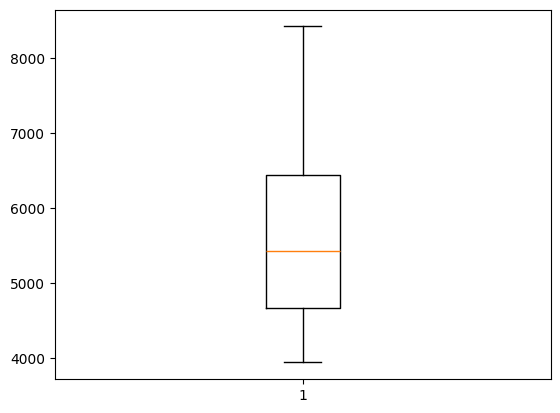

In [95]:
plt.boxplot(df4['price_per_sqft'])

In [96]:
df4.location=df4.location.astype(str).apply(lambda x:x.strip())
location_stats=df4['location'].value_counts(ascending=False)
location_stats

,count
location,
other,2687
Whitefield,393
Sarjapur Road,310
Kanakpura Road,241
Thanisandra,181
...,...
Parappana Agrahara,2
Sarakki Nagar,2
2nd Stage Nagarbhavi,2


In [97]:
location_stats_less_than_10 = location_stats[location_stats <= 10]
len(location_stats_less_than_10)

13

In [98]:
df4.location.nunique()

130

In [99]:
df4.location=df4.location.apply(lambda x:'other'if x in location_stats_less_than_10 else x)
len(df4.location.unique())

117

In [101]:
df4.head(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,price_per_sqft
1,Plot Area,Ready To Move,other,4 Bedroom,Theanmp,2600.0,5.0,3.0,120.00,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440.0,2.0,3.0,62.00,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521.0,3.0,1.0,95.00,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200.0,2.0,1.0,51.00,4250.000000
6,Super built-up Area,18-May,other,4 BHK,Jaades,2732.0,4.0,NaN,204.00,7467.057101
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310.0,3.0,1.0,63.25,4828.244275
14,Plot Area,Ready To Move,Sarjapur,3 Bedroom,Skityer,2250.0,3.0,2.0,148.00,6577.777778
15,Super built-up Area,Ready To Move,Mysore Road,2 BHK,PrntaEn,1175.0,2.0,2.0,73.50,6255.319149
16,Super built-up Area,Ready To Move,Bisuvanahalli,3 BHK,Prityel,1180.0,3.0,2.0,48.00,4067.796610
19,Super built-up Area,Ready To Move,other,2 BHK,NaN,1100.0,2.0,2.0,48.00,4363.636364


In [126]:
if 'price_per_sqft' in df4.columns:
    df4 = df4.drop(columns='price_per_sqft')
else:
    print("Column 'price_per_sqft' not found in df4. Skipping drop operation.")

Column 'price_per_sqft' not found in df4. Skipping drop operation.


In [114]:
!pip install category_encoders

In [117]:
from category_encoders import OneHotEncoder

In [139]:
x=df4.drop(['price'],axis='columns')

# Drop 'society' column due to a very high number of missing values.
if 'society' in x.columns:
    x = x.drop(columns='society')

# Impute missing numerical values for 'bath' and 'balcony' with their median.
# First, ensure these columns exist and are numeric.
numerical_cols_to_impute = ['bath', 'balcony']
for col in numerical_cols_to_impute:
    if col in x.columns:
        x[col] = pd.to_numeric(x[col], errors='coerce') # Ensure numerical type, coerce non-numeric to NaN
        if x[col].isnull().any():
            median_val = x[col].median()
            x[col] = x[col].fillna(median_val)

In [122]:
y=df4.price

In [138]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [142]:
model=make_pipeline(OneHotEncoder(),LinearRegression())
model.fit(x_train,y_train)


Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['area_type', 'availability', 'location',
                                     'size'])),
                ('linearregression', LinearRegression())])

In [147]:
y_pred=model.predict(x_test)
mae=mean_absolute_error(y_test,y_pred)
mae

13.80537212885868

In [150]:
def predict_price(input_data: dict): # We accept the input features as a dictionary, making it suitable for real-world use(like in Apps and APIs)
    '''
    Predict house price based on input features

    Parameters:
    input_data (dict): Feature-value pairs. Expected keys are 'location', 'total_sqft', 'bath', and optionally 'size' or 'bedrooms', 'area_type', 'availability', 'balcony'.

    Returns:
    float: Predicted house price
    '''
    # The model was trained on these columns in x_train (Variable #10 from kernel state):
    # 'area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony'
    expected_columns = ['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony']

    # Initialize a dictionary with default values for all expected columns.
    # These defaults should ideally be derived from the training data (e.g., modes for categorical, medians for numerical)
    # For this fix, sensible common defaults are chosen.
    prediction_input = {
        'area_type': 'Super built-up Area',  # A common value from the dataset
        'availability': 'Ready To Move',      # A common value from the dataset
        'location': 'other',                  # Default for less frequent locations
        'size': '2 BHK',                      # A common size
        'total_sqft': 1200.0,                 # A reasonable average
        'bath': 2.0,                          # A common number of bathrooms
        'balcony': 1.0                        # A common number of balconies
    }

    # Update prediction_input with the values provided in input_data
    for key, value in input_data.items():
        if key == 'bedrooms':
            # Map 'bedrooms' from input_data to 'size' for the model
            prediction_input['size'] = f"{value} BHK"
        elif key in expected_columns:
            prediction_input[key] = value
        # Optional: else block for handling unexpected input_data keys, e.g., print a warning

    # Create a DataFrame from the processed input, ensuring column order matches training data
    input_df = pd.DataFrame([prediction_input], columns=expected_columns)

    # Ensure numerical types are correct
    input_df['total_sqft'] = pd.to_numeric(input_df['total_sqft'])
    input_df['bath'] = pd.to_numeric(input_df['bath'])
    input_df['balcony'] = pd.to_numeric(input_df['balcony'])

    return model.predict(input_df)[0] # running the same preprocessing and regression steps.
    # [0] ɵ is used to extract the first (and only) value from the prediction output.
    # model.predict() returns a NumPy array, and since we predict for a single row, [0] retrieves the single predicted price.


# Example prediction
example_house = {
    'location': 'Whitefield',
    'total_sqft': 1200,
    'bath': 2,
    'bedrooms':2
}

print("Predicted Price:", predict_price(example_house))

Predicted Price: 70.6142455254186
